In [1]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!git clone https://github.com/Ankitj3345/airline-complaint-intelligence.git

Cloning into 'airline-complaint-intelligence'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 55 (delta 20), reused 44 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 434.01 KiB | 12.06 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [3]:
%cd airline-complaint-intelligence

/content/airline-complaint-intelligence


In [4]:
!ls

api  app  notebooks  README.md	reports  requirements.txt  src	tests


In [5]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [6]:
import transformers
import datasets
import torch

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.is_available())

Transformers: 5.16.1
Datasets: 4.8.5
PyTorch: 2.11.0+cu128
GPU: True


In [10]:
import pandas as pd



df = pd.read_csv('../flight_dataset.csv')

In [11]:
df = df[["text", "airline_sentiment"]].copy()

In [12]:
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [13]:
print(df.isnull().sum())

text                 0
airline_sentiment    0
dtype: int64


In [25]:
df.duplicated().sum()

np.int64(188)

In [26]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["airline_sentiment"]
)

In [28]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [29]:
from datasets import Dataset

In [30]:
train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

In [32]:
print(train_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 11712
})


In [33]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [34]:
sample_text = "My flight was delayed for five hours."

tokens = tokenizer(sample_text)

print(tokens)

{'input_ids': [101, 2026, 3462, 2001, 8394, 2005, 2274, 2847, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [35]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [36]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/11712 [00:00<?, ? examples/s]

Map:   0%|          | 0/2928 [00:00<?, ? examples/s]

In [37]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label={
        0: "negative",
        1: "neutral",
        2: "positive"
    },
    label2id={
        "negative": 0,
        "neutral": 1,
        "positive": 2
    }
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print("Using:", device)

Using: cuda


In [39]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [40]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./models/distilbert",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none"
)

In [41]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

In [42]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.432888,0.423087,0.832650,0.787348,0.771054,0.778446
2,0.329041,0.434489,0.843238,0.800193,0.790503,0.795203
3,0.212418,0.498257,0.842213,0.796724,0.789268,0.792888


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2196, training_loss=0.3573146865233263, metrics={'train_runtime': 447.7979, 'train_samples_per_second': 78.464, 'train_steps_per_second': 4.904, 'total_flos': 1163614380834816.0, 'train_loss': 0.3573146865233263, 'epoch': 3.0})

In [43]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.212418,0.434489,3,0.843238,0.800193,0.790503,0.795203


{'eval_loss': 0.4344885051250458, 'eval_accuracy': 0.8432377049180327, 'eval_precision': 0.8001933547768365, 'eval_recall': 0.7905027780353561, 'eval_f1': 0.7952033220026533}


In [44]:
MODEL_PATH = "/content/drive/MyDrive/airline-project/models/distilbert-sentiment"

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [45]:
predictions = trainer.predict(tokenized_test)

In [46]:
logits = predictions.predictions

In [47]:
y_pred = np.argmax(logits, axis=1)

In [48]:
y_true = predictions.label_ids

In [49]:
print(y_pred[:10])
print(y_true[:10])

[1 1 0 0 0 0 0 2 0 1]
[1 2 0 0 0 0 1 0 0 0]


In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.90      0.92      0.91      1835
     neutral       0.70      0.68      0.69       620
    positive       0.80      0.78      0.79       473

    accuracy                           0.84      2928
   macro avg       0.80      0.79      0.80      2928
weighted avg       0.84      0.84      0.84      2928



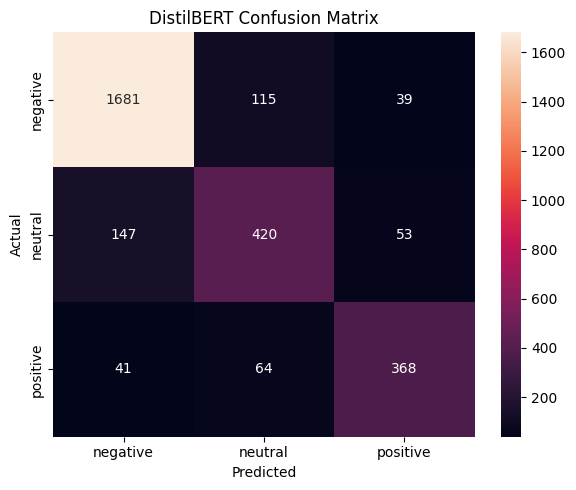

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")
plt.tight_layout()
plt.show()

In [52]:
import torch

probabilities = torch.softmax(
    torch.tensor(logits),
    dim=1
).numpy()

In [53]:
print(probabilities[:5])

[[0.09471537 0.8530871  0.05219747]
 [0.12573531 0.7829932  0.09127147]
 [0.9889903  0.00830021 0.00270952]
 [0.99050397 0.00831387 0.00118223]
 [0.9927579  0.00526288 0.00197918]]


In [54]:
confidence = probabilities.max(axis=1)

In [55]:
predicted_class = probabilities.argmax(axis=1)

In [56]:
results_df = test_df.copy()

results_df["predicted_label"] = predicted_class
results_df["confidence"] = confidence

results_df["predicted_sentiment"] = label_encoder.inverse_transform(
    predicted_class
)

results_df["actual_sentiment"] = label_encoder.inverse_transform(
    y_true
)

In [57]:
results_df[
    [
        "text",
        "actual_sentiment",
        "predicted_sentiment",
        "confidence"
    ]
].head(10)

,text,actual_sentiment,predicted_sentiment,confidence
2998,@united past,neutral,neutral,0.853087
7719,@JetBlue would you say a delay is more likely?...,positive,neutral,0.782993
8575,"@JetBlue I cheated on you, and I'm sorry. I'll...",negative,negative,0.988990
618,@united disappointed that u didnt honor my $10...,negative,negative,0.990504
11741,@USAirways The airline is embarrassing itself....,negative,negative,0.992758
14246,@AmericanAir my flight has been delayed &amp; ...,negative,negative,0.994793
4006,@united This link in your tweet goes to someon...,neutral,negative,0.619679
5778,@SouthwestAir BETSY is the BESTY! Gettin' stuc...,negative,positive,0.925590
9624,@USAirways How many agents do you have working...,negative,negative,0.954225
4686,@SouthwestAir When will the flight resume? I d...,negative,neutral,0.899179


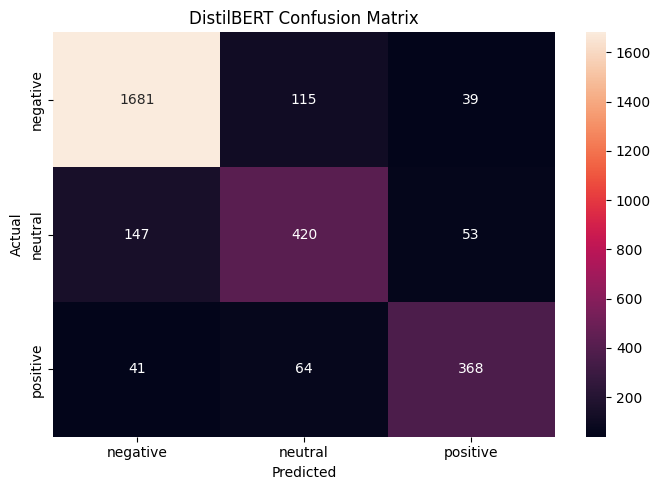

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/airline-project/distilbert_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [61]:
!find /content/drive/MyDrive -type d -name "airline-project"


/content/drive/MyDrive/airline-project


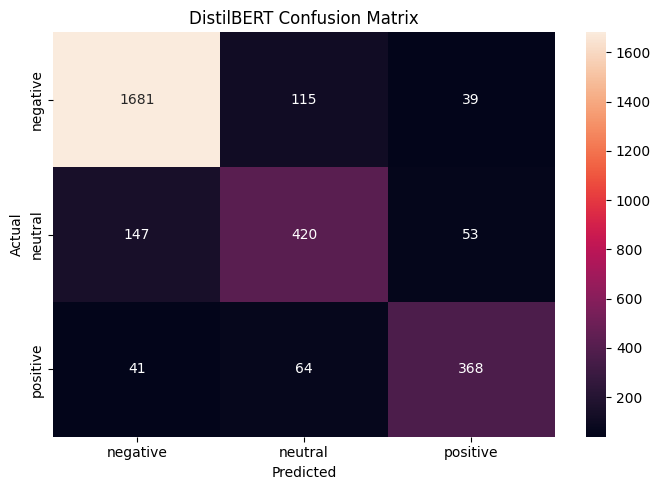

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.tight_layout()

In [63]:
plt.savefig(
    "/content/drive/MyDrive/airline-project/distilbert_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [66]:
BASE_PATH = "/content/drive/MyDrive/airline-project"

!find "$BASE_PATH" -maxdepth 3 -print

/content/drive/MyDrive/airline-project
/content/drive/MyDrive/airline-project/models
/content/drive/MyDrive/airline-project/models/distilbert-sentiment
/content/drive/MyDrive/airline-project/models/distilbert-sentiment/training_args.bin
/content/drive/MyDrive/airline-project/models/distilbert-sentiment/model.safetensors
/content/drive/MyDrive/airline-project/models/distilbert-sentiment/config.json
/content/drive/MyDrive/airline-project/models/distilbert-sentiment/tokenizer_config.json
/content/drive/MyDrive/airline-project/models/distilbert-sentiment/tokenizer.json
/content/drive/MyDrive/airline-project/distilbert_predictions.csv
/content/drive/MyDrive/airline-project/distilbert_confusion_matrix.png


In [67]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/airline-project/distilbert_confusion_matrix.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# DistilBERT metrics
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

# Create dataframe
distilbert_metrics = pd.DataFrame({
    "Model": ["DistilBERT"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1]
})

distilbert_metrics

,Model,Accuracy,Precision,Recall,F1_Score
0,DistilBERT,0.843238,0.800193,0.790503,0.795203


In [69]:
distilbert_metrics.to_csv(
    "/content/drive/MyDrive/airline-project/distilbert_metrics.csv",
    index=False
)

In [70]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/airline-project/distilbert_metrics.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>